In [3]:
!pip install contractions
!pip install wordcloud
!pip install gensim
!pip install numpy
!pip install jax==0.6.0 jaxlib==0.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 MB 4.8 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
import nltk
import gensim.downloader as api

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping


ModuleNotFoundError: No module named 'contractions'

In [9]:
# ============================================================
# CELL 3: DOWNLOAD NLTK DATA
# ============================================================

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [6]:
from google.colab import files

uploaded = files.upload()


Saving Hotel_Reviews.csv to Hotel_Reviews.csv


In [10]:
# ============================================================
# CELL TO LOAD CSV INTO DATAFRAME
# ============================================================

df = pd.read_csv('Hotel_Reviews.csv')
print(df.columns)
print(df.head())


Index(['Review', 'Rating'], dtype='object')
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5


In [8]:
# ============================================================
# CELL 6: SELECT TEXT AND LABEL COLUMNS
# ============================================================

# CHANGE COLUMN NAMES IF NEEDED

text_column = 'Review'
label_column = 'Rating'

reviews = df[text_column]
ratings = df[label_column]

In [15]:
# ============================================================
# CELL 7: TEXT CLEANING FUNCTION
# ============================================================

import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re # Import re module if not already imported

nltk.download('stopwords', quiet=True) # Ensure stopwords are available
nltk.download('wordnet', quiet=True) # Ensure wordnet is available

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)


In [16]:
# ============================================================
# CELL 8: APPLY CLEANING
# ============================================================

reviews_cleaned = reviews.apply(clean_text)

print(reviews_cleaned.head())

0    nice hotel expensive parking got good deal sta...
1    ok nothing special charge diamond member hilto...
2    nice room experience hotel monaco seattle good...
3    unique great stay wonderful time hotel monaco ...
4    great stay great stay went seahawk game awesom...
Name: Review, dtype: object


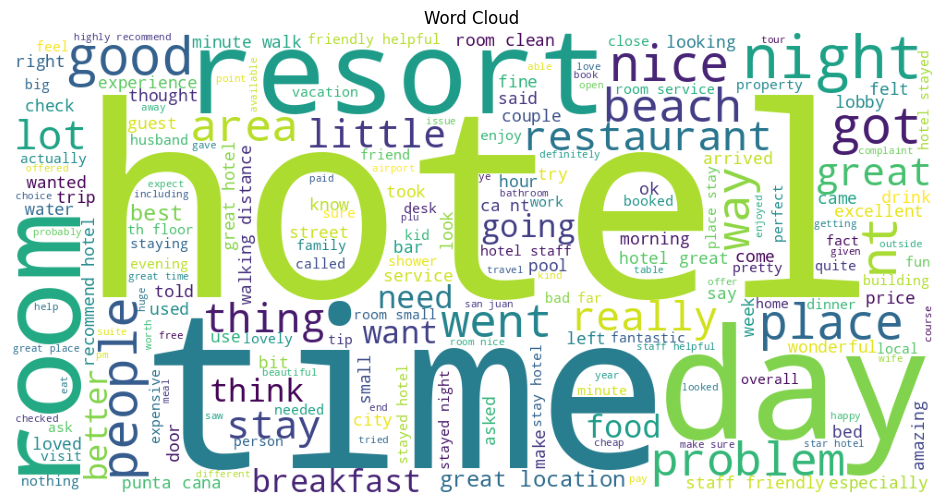

In [18]:
# ============================================================
# CELL 9: WORD CLOUD
# ============================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(reviews_cleaned)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud')
plt.show()

In [20]:
# ============================================================
# CELL 10: TOKENIZATION
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(reviews_cleaned)

sequences = tokenizer.texts_to_sequences(reviews_cleaned)


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.6.0, so it will not be used.
  warnings.warn(


In [22]:
# ============================================================
# CELL 11: PADDING
# ============================================================

from tensorflow.keras.preprocessing.sequence import pad_sequences

sequence_lengths = [len(seq) for seq in sequences]

max_length = int(np.percentile(sequence_lengths, 95))

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print("Max Length:", max_length)


Max Length: 256


In [24]:
# ============================================================
# CELL 12: TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Convert labels from 1-5 to 0-4

ratings = ratings - 1

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    ratings,
    test_size=0.2,
    random_state=42,
    stratify=ratings
)

print(X_train.shape)
print(X_test.shape)


(16392, 256)
(4099, 256)


In [30]:
# ============================================================
# CELL 13: EARLY STOPPING
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [31]:
# ============================================================
# CELL 14: BUILD SIMPLE RNN MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense

vocab_size = max_words
embedding_dim = 128

model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.3))

model_rnn.add(Dense(64, activation='relu'))

model_rnn.add(Dense(5, activation='softmax'))

model_rnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ============================================================
# CELL 15: COMPILE RNN MODEL
# ============================================================

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [33]:
# ============================================================
# CELL 16: TRAIN RNN MODEL
# ============================================================

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 3.0504e-04 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan


In [40]:
# ============================================================
# CELL 17: EVALUATE RNN MODEL
# ============================================================

from sklearn.metrics import classification_report, accuracy_score

rnn_predictions = model_rnn.predict(X_test)

rnn_predicted_labels = np.argmax(
    rnn_predictions,
    axis=1
)

print(classification_report(
    y_test,
    rnn_predicted_labels
))

print(
    "Accuracy:",
    accuracy_score(y_test, rnn_predicted_labels)
)


129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       284
           0       0.09      1.00      0.16       359
           1       0.00      0.00      0.00       437
           2       0.00      0.00      0.00      1208
           3       0.00      0.00      0.00      1811

    accuracy                           0.09      4099
   macro avg       0.02      0.20      0.03      4099
weighted avg       0.01      0.09      0.01      4099

Accuracy: 0.08758233715540376


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


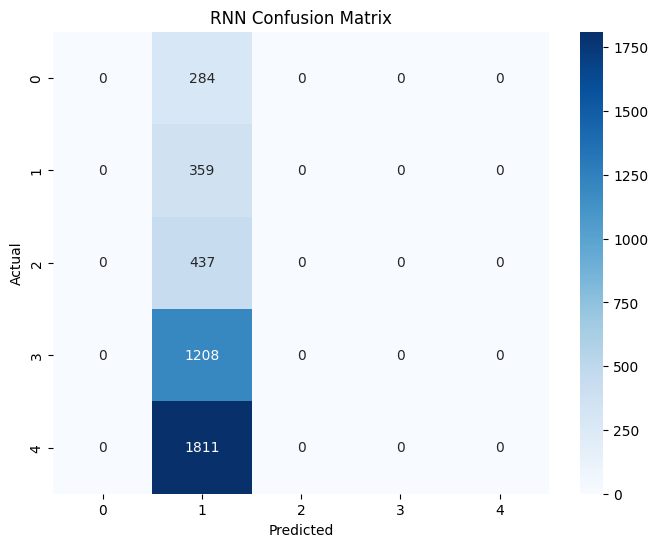

In [41]:
# ============================================================
# CELL 18: RNN CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rnn_predicted_labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RNN Confusion Matrix')

plt.show()

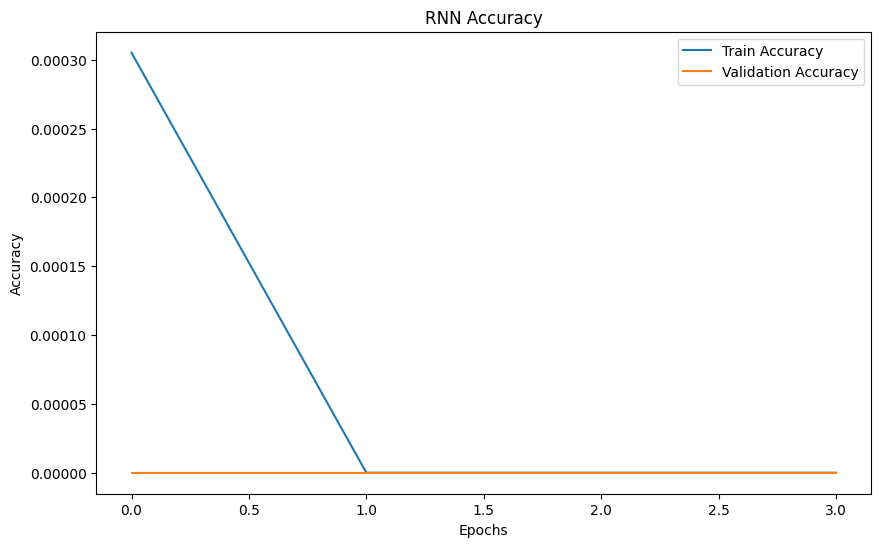

In [38]:
# ============================================================
# CELL 19: RNN ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    history_rnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title('RNN Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

In [42]:
# ============================================================
# CELL 20: BUILD LSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.3))

model_lstm.add(Dense(64, activation='relu'))

model_lstm.add(Dense(5, activation='softmax'))

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
# ============================================================
# CELL 21: COMPILE LSTM MODEL
# ============================================================

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [44]:
# ============================================================
# CELL 22: TRAIN LSTM MODEL
# ============================================================

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.0886 - loss: nan - val_accuracy: 0.0927 - val_loss: nan
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0862 - loss: nan - val_accuracy: 0.0927 - val_loss: nan
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0862 - loss: nan - val_accuracy: 0.0927 - val_loss: nan


In [45]:
# ============================================================
# CELL 23: EVALUATE LSTM MODEL
# ============================================================

lstm_predictions = model_lstm.predict(X_test)

lstm_predicted_labels = np.argmax(
    lstm_predictions,
    axis=1
)

print(classification_report(
    y_test,
    lstm_predicted_labels
))

print(
    "Accuracy:",
    accuracy_score(y_test, lstm_predicted_labels)
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       284
           0       0.09      1.00      0.16       359
           1       0.00      0.00      0.00       437
           2       0.00      0.00      0.00      1208
           3       0.00      0.00      0.00      1811

    accuracy                           0.09      4099
   macro avg       0.02      0.20      0.03      4099
weighted avg       0.01      0.09      0.01      4099

Accuracy: 0.08758233715540376


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


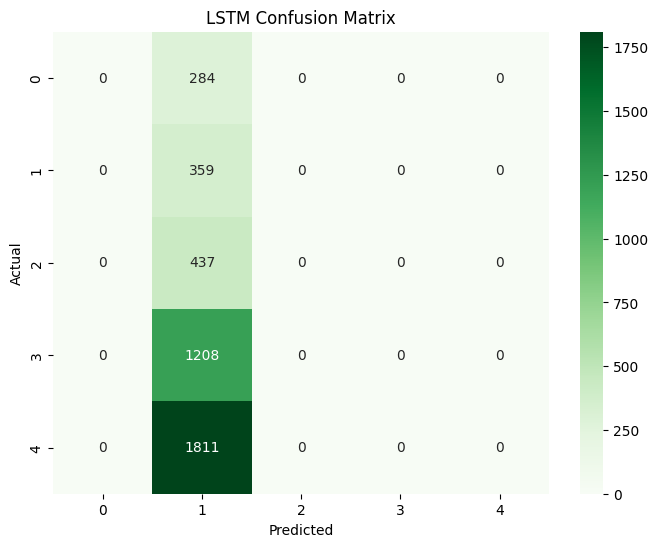

In [46]:
# ============================================================
# CELL 24: LSTM CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    lstm_predicted_labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('LSTM Confusion Matrix')

plt.show()

In [48]:
# ============================================================
# CELL 25: LOAD WORD2VEC MODEL
# ============================================================

import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [50]:
# ============================================================
# CELL 26: CREATE EMBEDDING MATRIX
# ============================================================

word_index = tokenizer.word_index

embedding_dim = 50

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, i in word_index.items():

    if i >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

In [51]:
# ============================================================
# CELL 27: BUILD WORD2VEC LSTM MODEL
# ============================================================

model_w2v = Sequential()

model_w2v.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

model_w2v.add(LSTM(64))

model_w2v.add(Dropout(0.3))

model_w2v.add(Dense(64, activation='relu'))

model_w2v.add(Dense(5, activation='softmax'))

model_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [52]:
# ============================================================
# CELL 28: COMPILE WORD2VEC MODEL
# ============================================================

model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [53]:
# ============================================================
# CELL 29: TRAIN WORD2VEC MODEL
# ============================================================

history_w2v = model_w2v.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.0862 - loss: nan - val_accuracy: 0.0927 - val_loss: nan
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0862 - loss: nan - val_accuracy: 0.0927 - val_loss: nan
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.0862 - loss: nan - val_accuracy: 0.0927 - val_loss: nan


In [54]:
# ============================================================
# CELL 30: EVALUATE WORD2VEC MODEL
# ============================================================

w2v_predictions = model_w2v.predict(X_test)

w2v_predicted_labels = np.argmax(
    w2v_predictions,
    axis=1
)

print(classification_report(
    y_test,
    w2v_predicted_labels
))

print(
    "Accuracy:",
    accuracy_score(y_test, w2v_predicted_labels)
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       284
           0       0.09      1.00      0.16       359
           1       0.00      0.00      0.00       437
           2       0.00      0.00      0.00      1208
           3       0.00      0.00      0.00      1811

    accuracy                           0.09      4099
   macro avg       0.02      0.20      0.03      4099
weighted avg       0.01      0.09      0.01      4099

Accuracy: 0.08758233715540376


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
# ============================================================
# CELL 31: MODEL COMPARISON
# ============================================================

results = {
    'Model': [
        'RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        accuracy_score(y_test, rnn_predicted_labels),
        accuracy_score(y_test, lstm_predicted_labels),
        accuracy_score(y_test, w2v_predicted_labels)
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

           Model  Accuracy
0            RNN  0.087582
1           LSTM  0.087582
2  Word2Vec LSTM  0.087582


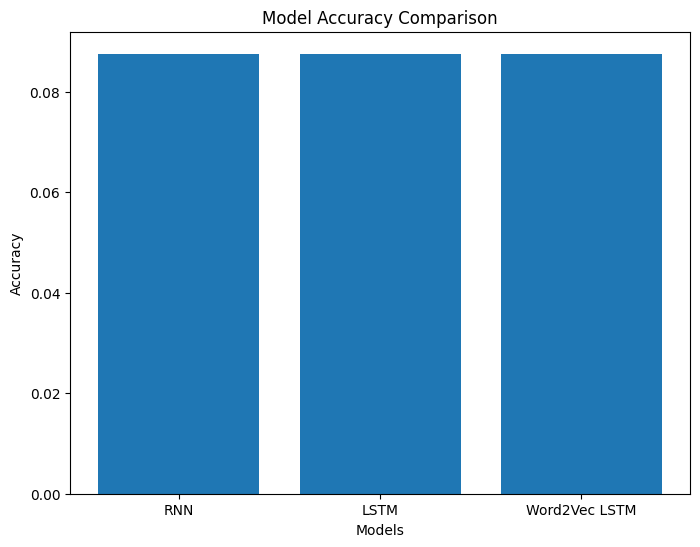

In [56]:
# ============================================================
# CELL 32: PLOT MODEL COMPARISON
# ============================================================

plt.figure(figsize=(8,6))

plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.title('Model Accuracy Comparison')

plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()

In [57]:
# ============================================================
# CELL 33: REAL TIME PREDICTION FUNCTION
# ============================================================

def predict_review(review_text):

    cleaned = clean_text(review_text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    prediction = model_lstm.predict(padded)

    predicted_rating = np.argmax(
        prediction,
        axis=1
    )[0]

    print("Predicted Rating:", predicted_rating + 1)

In [58]:
# ============================================================
# CELL 33: REAL TIME PREDICTION FUNCTION
# ============================================================

def predict_review(review_text):

    cleaned = clean_text(review_text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    prediction = model_lstm.predict(padded)

    predicted_rating = np.argmax(
        prediction,
        axis=1
    )[0]

    print("Predicted Rating:", predicted_rating + 1)

In [59]:
# ============================================================
# CELL 34: TEST REAL TIME PREDICTION
# ============================================================

sample_review = """
The hotel was very clean and the staff were friendly.
"""

predict_review(sample_review)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Rating: 1


In [60]:
# ============================================================
# CELL 35: SAVE MODEL
# ============================================================

model_lstm.save('hotel_review_lstm_model.h5')